# **🚚 Cargo Weight & Balance Optimization Model**
**Objective** : Automate the placement of physical cargo pallets (Unit Load Devices - ULDs) across an aircraft's main and lower decks to ensure total center of gravity (CG) boundaries fall strictly within certified structural flight limits.
**The Math & Architecture** : This is a multi-constrained 3D Bin Packing Problem solved via a hybrid heuristic approach or a Deep Reinforcement Learning (DRL) agent using a Proximal Policy Optimization (PPO) framework. The action space is the coordinate placement grid within the aircraft hold. The reward function penalizes violations of structural constraints and rewards tighter alignment with the target Zero-Fuel Center of Gravity (ZFCG) position:

$$
\text{Reward} = -(\alpha \cdot \vert{}\text{Target CG} - \text{Current CG}\vert{} + \beta \cdot \text{Volume Wastage})
$$

This dataset contains five months of real-world cargo tracking records from a forwarding company's Cargo 2000 system, cleaned up to track how physical goods move through supply chains. By analyzing these messages, the creators reconstructed 3,942 shipping processes—covering nearly 8,000 transport legs—and recorded both the planned and actual durations (in minutes) for each step alongside airport locations. To clean and protect the data, incomplete or canceled shipments were removed, tracking inconsistencies were corrected, and sensitive business details like flight numbers and airport codes were anonymized or removed.

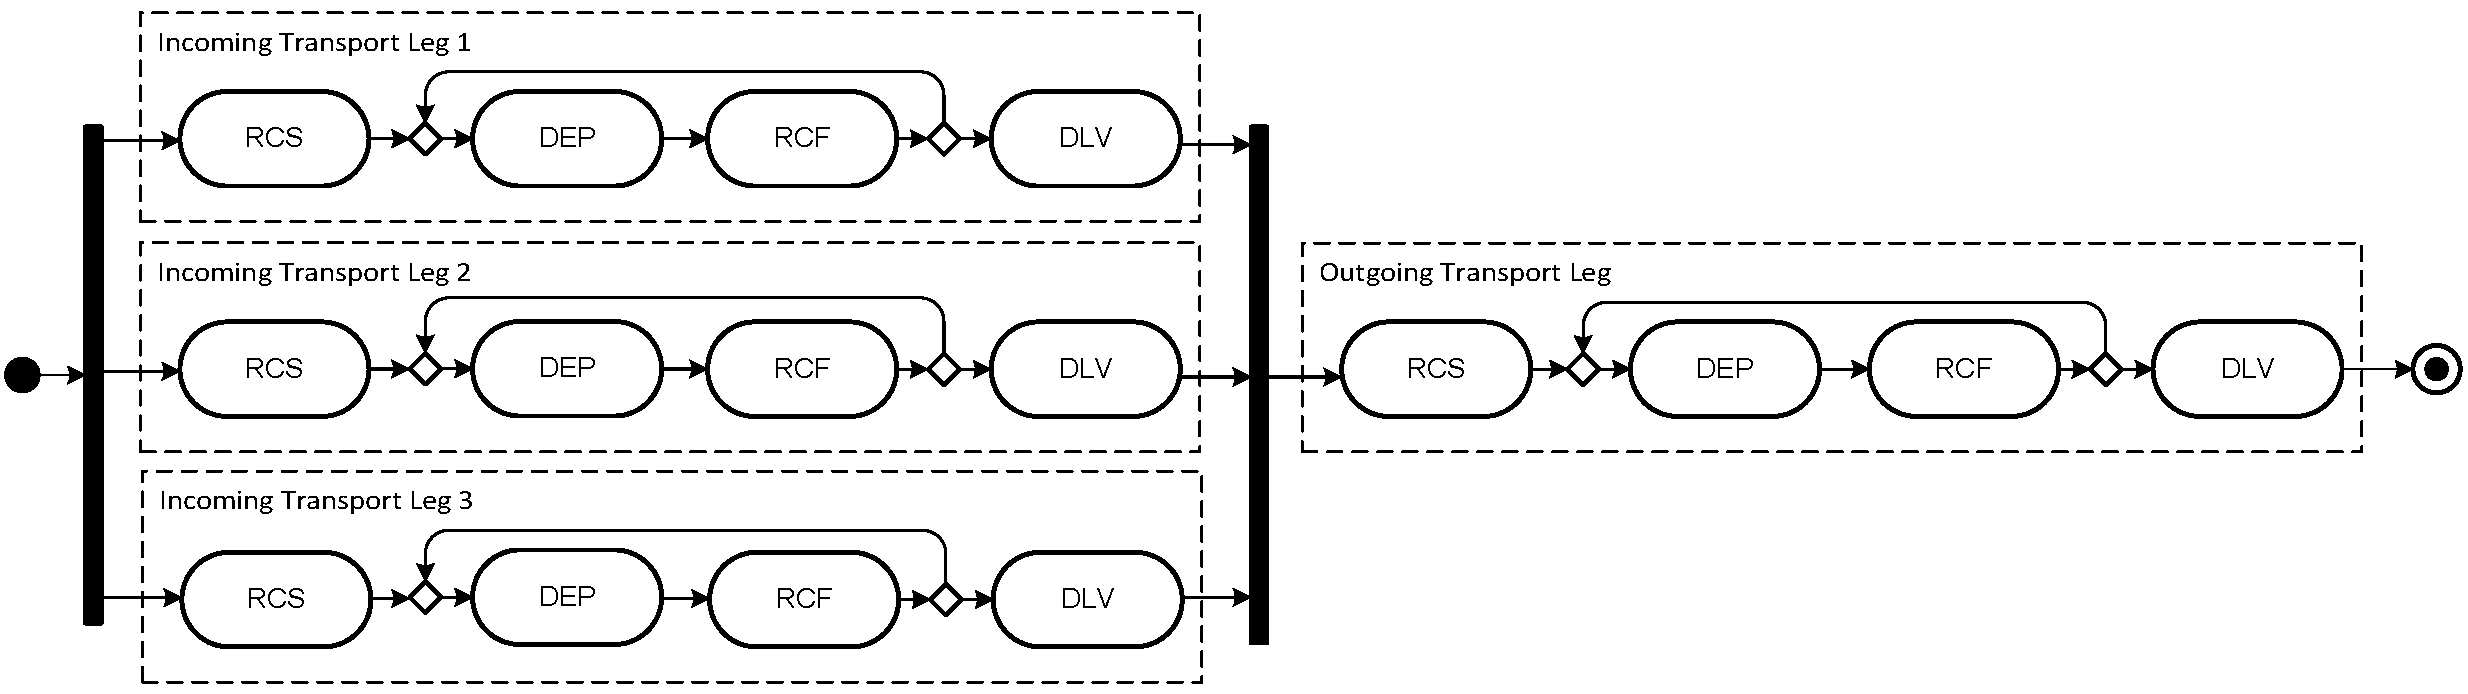

## **Dataset Overview: Cargo 2000 (Cargo iQ) Execution Traces**

This dataset tracks freight operational milestones, leg segments, planned vs. actual durations, and airport hops for incoming and outgoing transport legs across global supply chains.

### General Metadata Summary
| Attribute | Value |
| :--- | :--- |
| **Total Observations (Rows)** | `3,943` |
| **Total Features (Columns)** | `98` |
| **Data Types** | `float64` (26 features), `object` (72 features) |
| **Memory Footprint** | `~2.9+ MB` |
| **Missing Values** | 1 record missing across all columns (`3,942` non-null records) |


### Feature Schema Breakdown

The 98 features follow a standardized prefix naming convention depending on the transport leg stage:
* **`i1_`**, **`i2_`**, **`i3_`**: Incoming Transport Legs 1, 2, and 3
* **`o_`**: Outgoing Transport Leg
* **`nr`**: Unique process instance ID (`1` to `3,942`)
* **`legs`**: Total count of incoming legs in the overall process (`1` to `3`)

| Variable Pattern | Field Type / Suffix | Domain / Range | Description |
| :--- | :--- | :--- | :--- |
| **`*_legid`** | Identifier | `[1 ... 14,664]` | Unique identifier for the specific transport leg (includes empty legs). |
| **`*_rcs_p` / `*_rcs_e`** | Planned / Effective | Duration (`mins`) | **Freight Check-in (RCS)**: Planned vs. actual execution duration. |
| **`*_dep_N_p` / `*_dep_N_e`** | Planned / Effective | Duration (`mins`) | **Departure Segment $N$**: Planned vs. actual segment flight duration ($N \in \{1, 2, 3\}$). |
| **`*_dep_N_place`** | Categorical ID | `[100 ... 816]` | **Departure Location**: Masked airport identifier for confidentiality. |
| **`*_rcf_N_p` / `*_rcf_N_e`** | Planned / Effective | Duration (`mins`) | **Arrival Segment $N$ (RCF)**: Planned vs. actual segment arrival duration ($N \in \{1, 2, 3\}$). |
| **`*_rcf_N_place`** | Categorical ID | `[100 ... 816]` | **Arrival Location**: Masked airport identifier for confidentiality. |
| **`*_dlv_p` / `*_dlv_e`** | Planned / Effective | Duration (`mins`) | **Freight Delivery (DLV)**: Planned vs. actual delivery phase duration. |
| **`*_hops`** | Discrete Integer | `[1 ... 4]` | Total number of airport transfer segments/hops in the leg. |
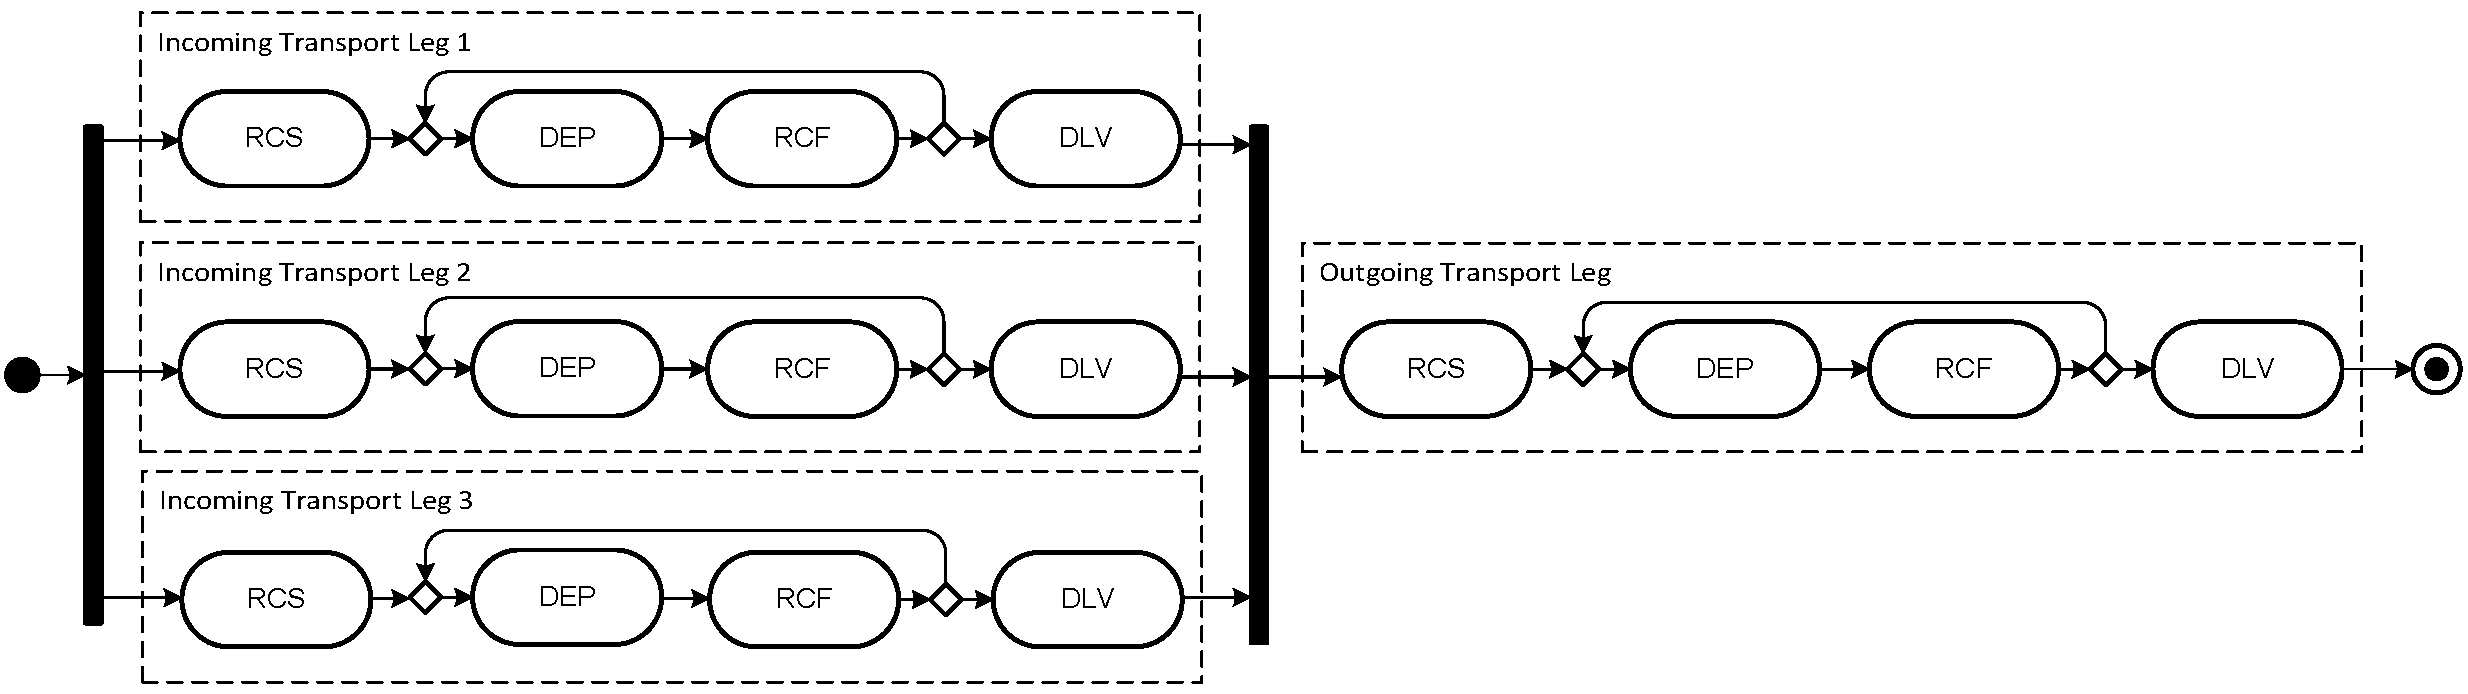

In [1]:
%pip install stable_baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 9.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from matplotlib import pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/crawford/cargo-2000-dataset/c2k_data_comma.csv
/kaggle/input/datasets/crawford/cargo-2000-dataset/column_descriptions.txt


In [3]:
data = pd.read_csv('/kaggle/input/datasets/crawford/cargo-2000-dataset/c2k_data_comma.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3943 entries, 0 to 3942
Data columns (total 98 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   nr              3942 non-null   float64
 1   i1_legid        3942 non-null   float64
 2   i1_rcs_p        3942 non-null   float64
 3   i1_rcs_e        3942 non-null   float64
 4   i1_dep_1_p      3942 non-null   float64
 5   i1_dep_1_e      3942 non-null   float64
 6   i1_dep_1_place  3942 non-null   float64
 7   i1_rcf_1_p      3942 non-null   float64
 8   i1_rcf_1_e      3942 non-null   float64
 9   i1_rcf_1_place  3942 non-null   float64
 10  i1_dep_2_p      3942 non-null   object 
 11  i1_dep_2_e      3942 non-null   object 
 12  i1_dep_2_place  3942 non-null   object 
 13  i1_rcf_2_p      3942 non-null   object 
 14  i1_rcf_2_e      3942 non-null   object 
 15  i1_rcf_2_place  3942 non-null   object 
 16  i1_dep_3_p      3942 non-null   object 
 17  i1_dep_3_e      3942 non-null   o

In [4]:
data.isnull().sum()

nr               1
i1_legid         1
i1_rcs_p         1
i1_rcs_e         1
i1_dep_1_p       1
                ..
o_rcf_3_place    1
o_dlv_p          1
o_dlv_e          1
o_hops           1
legs             1
Length: 98, dtype: int64

In [5]:
# 1. Drop the single fully missing/corrupted row if index 3942 is empty
data = data.dropna(subset=['nr']).copy()

# 2. Identify all columns with 'object' dtype (except actual string categorical IDs if any)
object_cols = data.select_dtypes(include=['object']).columns

# 3. Coerce object columns to numeric (invalid strings/question marks will become NaN)
for col in object_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# 4. Fill NaNs resulting from non-existent legs/hops with 0
data = data.fillna(0)

print(f"Cleaned dataset shape: {data.shape}")
print(f"Remaining object columns: {data.select_dtypes(include=['object']).shape[1]}")

Cleaned dataset shape: (3942, 98)
Remaining object columns: 0


In [6]:
# 1. Calculate Delays across Leg 1 (Effective - Planned)
data['i1_checkin_delay'] = data['i1_rcs_e'] - data['i1_rcs_p']
data['i1_flight_delay']  = data['i1_dep_1_e'] - data['i1_dep_1_p']
data['i1_arrival_delay'] = data['i1_rcf_1_e'] - data['i1_rcf_1_p']

# 2. Compute Total Planned Journey Duration (RCS Check-in to Delivery)
data['total_planned_duration'] = data['i1_rcs_p'] + data['i1_dep_1_p'] + data['i1_rcf_1_p'] + data['i1_dlv_p']
data['total_effective_duration'] = data['i1_rcs_e'] + data['i1_dep_1_e'] + data['i1_rcf_1_e'] + data['i1_dlv_e']

# 3. Overall Shipment Schedule Variance
data['total_delay'] = data['total_effective_duration'] - data['total_planned_duration']

# Inspect core delay distribution
data[['i1_checkin_delay', 'i1_flight_delay', 'total_delay']].describe()

,i1_checkin_delay,i1_flight_delay,total_delay
count,3942.000000,3942.000000,3942.000000
mean,-550.210046,505.516996,-1617.561898
std,701.440218,676.887032,5857.942703
min,-9325.000000,-1255.000000,-10207.000000
25%,-780.000000,65.000000,-4035.750000
50%,-344.000000,305.000000,-2993.500000
75%,-108.000000,740.000000,-534.250000
max,1200.000000,9273.000000,86060.000000


In [7]:
def generate_cargo_manifest(df_row, seed=None):
    """
    Converts a dataset row into physical Unit Load Devices (ULDs) / Pallets
    with generated weights and dimensions based on number of legs and hops.
    """
    if seed:
        np.random.seed(seed)
        
    num_legs = int(df_row['legs'])
    manifest = []
    
    # Standard IATA ULD Container Presets (Length, Width, Height in meters)
    uld_types = [
        {"type": "LD3", "dims": (1.56, 1.53, 1.63), "max_weight": 1588},
        {"type": "PMC Pallet", "dims": (2.44, 3.18, 1.62), "max_weight": 6800},
        {"type": "M1N Box", "dims": (2.44, 6.06, 2.44), "max_weight": 11340}
    ]
    
    for leg_idx in range(1, num_legs + 1):
        # Determine number of pallets derived from leg hops
        hops_col = f'i{leg_idx}_hops'
        num_pallets = int(df_row[hops_col]) if hops_col in df_row else 1
        num_pallets = max(1, num_pallets)  # Ensure at least 1 ULD per leg
        
        for p in range(num_pallets):
            uld = np.random.choice(uld_types)
            weight = np.random.uniform(500, uld['max_weight'])
            
            manifest.append({
                "process_id": int(df_row['nr']),
                "leg": leg_idx,
                "uld_type": uld['type'],
                "weight_kg": round(weight, 2),
                "length_m": uld['dims'][0],
                "width_m": uld['dims'][1],
                "height_m": uld['dims'][2],
                "volume_m3": round(uld['dims'][0] * uld['dims'][1] * uld['dims'][2], 2),
                "destination_airport": int(df_row[f'i{leg_idx}_rcf_1_place'])
            })
            
    return pd.DataFrame(manifest)

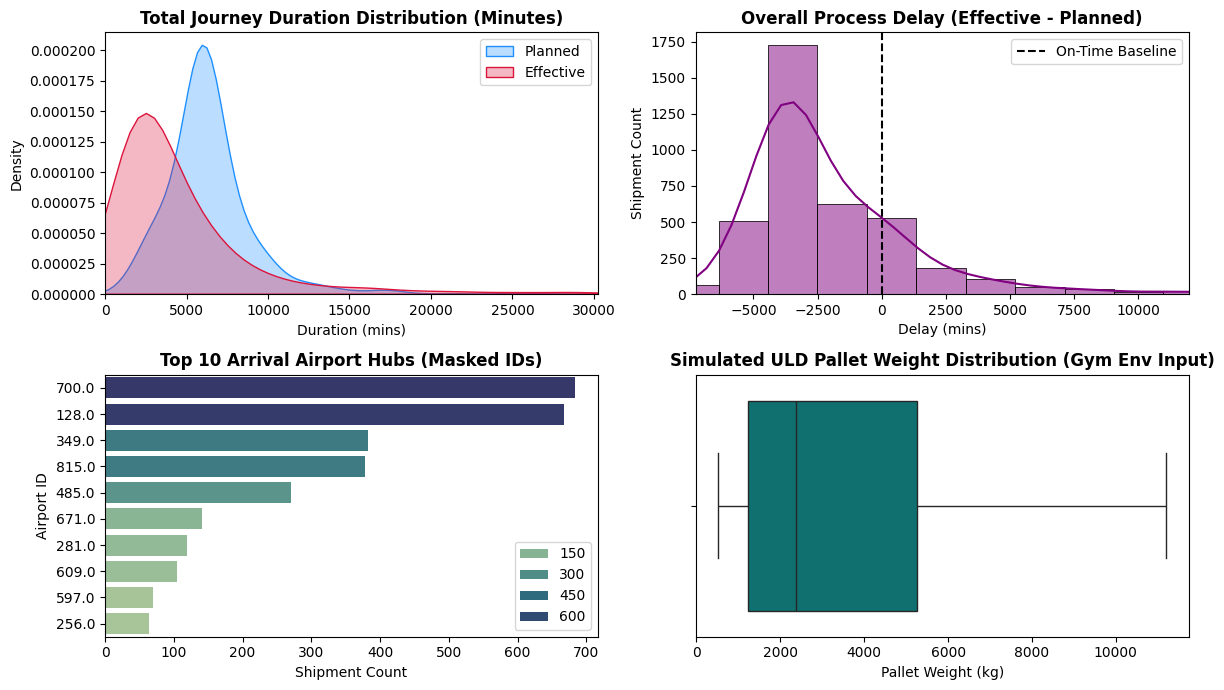


=== Gym Environment Readiness Check ===
Total Process Instances Ready: 3942
Average Legs Per Instance: 2.01
Simulated Average Payload Mass Per Instance: 3482.40 kg


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Subplot 1: Total Journey Duration Distribution (Planned vs. Effective)
sns.kdeplot(data['total_planned_duration'], ax=axes[0, 0], color='dodgerblue', label='Planned', fill=True, alpha=0.3)
sns.kdeplot(data['total_effective_duration'], ax=axes[0, 0], color='crimson', label='Effective', fill=True, alpha=0.3)
axes[0, 0].set_title("Total Journey Duration Distribution (Minutes)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Duration (mins)")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_xlim(0, data['total_effective_duration'].quantile(0.98))  # Clip extreme outliers for readability
axes[0, 0].legend()

# Subplot 2: Total Delay Variance Distribution
sns.histplot(data['total_delay'], ax=axes[0, 1], bins=50, color='purple', kde=True)
axes[0, 1].axvline(0, color='black', linestyle='--', linewidth=1.5, label='On-Time Baseline')
axes[0, 1].set_title("Overall Process Delay (Effective - Planned)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Delay (mins)")
axes[0, 1].set_ylabel("Shipment Count")
axes[0, 1].set_xlim(data['total_delay'].quantile(0.01), data['total_delay'].quantile(0.98))
axes[0, 1].legend()

# Subplot 3: Top 10 Active Arrival Airports
top_airports = data['i1_rcf_1_place'].value_counts().head(10)
sns.barplot(x=top_airports.values, y=top_airports.index.astype(str), ax=axes[1, 0], palette='crest', hue=top_airports.values)
axes[1, 0].set_title("Top 10 Arrival Airport Hubs (Masked IDs)", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Shipment Count")
axes[1, 0].set_ylabel("Airport ID")

# Subplot 4: Manifest Weight Simulation (Sampled across dataset)
# Sample manifests from 100 random rows to verify weight distribution for Gym Env
sample_weights = []
for idx in data.sample(min(100, len(data)), random_state=42).index:
    manifest = generate_cargo_manifest(data.loc[idx])
    sample_weights.extend(manifest['weight_kg'].tolist())

sns.boxplot(x=sample_weights, ax=axes[1, 1], color='teal')
axes[1, 1].set_title("Simulated ULD Pallet Weight Distribution (Gym Env Input)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Pallet Weight (kg)")

plt.tight_layout()
plt.show()


# 3. Environment Environment Pre-check
print("\n=== Gym Environment Readiness Check ===")
print(f"Total Process Instances Ready: {len(data)}")
print(f"Average Legs Per Instance: {data['legs'].mean():.2f}")
print(f"Simulated Average Payload Mass Per Instance: {np.mean(sample_weights):.2f} kg")

In [9]:
import gymnasium as gym
from gymnasium import spaces

class AircraftCargoEnv(gym.Env):
    """
    3D Aircraft Cargo Hold Bin-Packing Environment for Reinforcement Learning.
    Simulates cargo placement and Center of Gravity (CG) balancing for a Boeing 777F.
    """
    metadata = {"render_modes": ["human", "ascii"]}

    def __init__(self, data_df, grid_shape=(10, 4, 3), alpha=1.5, beta=0.5):
        super(AircraftCargoEnv, self).__init__()
        
        self.df = data_df
        self.grid_shape = grid_shape  # Length (X), Width (Y), Height (Z) grid voxels
        self.alpha = alpha            # Weight penalty multiplier for CG offset
        self.beta = beta              # Volume wastage penalty multiplier
        
        # Aircraft Physical Characteristics (Boeing 777F Simplified Model)
        self.max_hold_capacity_kg = 103000.0  # Max structural payload (kg)
        self.target_cg_x = grid_shape[0] / 2.0 # Target Zero-Fuel Center of Gravity (X-axis)
        
        # Action Space: (X, Y, Z) Discrete Placement Coordinates in the Hold Grid
        self.action_space = spaces.MultiDiscrete([grid_shape[0], grid_shape[1], grid_shape[2]])
        
        # Observation Space:
        # 1. 3D Voxel Grid Matrix representing occupied mass density
        # 2. Vector containing current package properties: [Weight, DimX, DimY, DimZ]
        # 3. Current Center of Gravity offset (delta_CG)
        self.observation_space = spaces.Dict({
            "occupancy_grid": spaces.Box(low=0.0, high=15000.0, shape=grid_shape, dtype=np.float32),
            "current_package": spaces.Box(low=0.0, high=12000.0, shape=(4,), dtype=np.float32),
            "delta_cg": spaces.Box(low=-10.0, high=10.0, shape=(1,), dtype=np.float32)
        })
        
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        # Initialize Hold Space
        self.hold_grid = np.zeros(self.grid_shape, dtype=np.float32)
        self.total_mass_kg = 0.0
        self.current_cg_x = self.target_cg_x
        
        # Sample a random process instance from cleaned dataset
        self.current_instance = self.df.sample(1).iloc[0]
        
        # Generate cargo items queue from sample instance
        self.cargo_queue = self._generate_cargo_queue(self.current_instance)
        self.current_item_idx = 0
        
        return self._get_obs(), {}

    def _generate_cargo_queue(self, row):
        """Generates package queue items for the current flight episode."""
        num_legs = int(row['legs'])
        queue = []
        for leg in range(1, num_legs + 1):
            # Sample 2-4 pallets per leg segment
            for _ in range(np.random.randint(2, 5)):
                w = np.random.uniform(800, 5000) # Weight in kg
                # Dimension in grid voxel units (LxWxH)
                dx, dy, dz = 2, 2, 1 
                queue.append({"weight": w, "dims": (dx, dy, dz)})
        return queue

    def _get_obs(self):
        if self.current_item_idx < len(self.cargo_queue):
            item = self.cargo_queue[self.current_item_idx]
            pkg_vec = np.array([item["weight"], *item["dims"]], dtype=np.float32)
        else:
            pkg_vec = np.zeros(4, dtype=np.float32)
            
        delta_cg = np.array([self.current_cg_x - self.target_cg_x], dtype=np.float32)
        
        return {
            "occupancy_grid": self.hold_grid.copy(),
            "current_package": pkg_vec,
            "delta_cg": delta_cg
        }

    def _calculate_cg(self):
        """Calculates Center of Gravity along Longitudinal (X) Aircraft Axis."""
        if self.total_mass_kg == 0:
            return self.target_cg_x
        
        # Grid indices along X-axis: 0, 1, 2, ..., grid_shape[0]-1
        x_indices = np.arange(self.grid_shape[0]).reshape(-1, 1, 1)
        mass_distribution = np.sum(self.hold_grid, axis=(1, 2))
        
        # Weighted centroid calculation
        cg_x = np.sum(x_indices.flatten() * mass_distribution) / self.total_mass_kg
        return cg_x

    def step(self, action):
        x, y, z = action
        item = self.cargo_queue[self.current_item_idx]
        w, (dx, dy, dz) = item["weight"], item["dims"]
        
        # Check Collision / Boundary Overlap
        if (x + dx > self.grid_shape[0]) or (y + dy > self.grid_shape[1]) or (z + dz > self.grid_shape[2]):
            # Penalty for invalid out-of-bounds placement action
            reward = -100.0
            terminated = False
            self.current_item_idx += 1
            if self.current_item_idx >= len(self.cargo_queue):
                terminated = True
            return self._get_obs(), reward, terminated, False, {"status": "out_of_bounds"}
            
        # Place package in voxel grid
        self.hold_grid[x:x+dx, y:y+dy, z:z+dz] += w
        self.total_mass_kg += w
        
        # Recalculate CG shift
        self.current_cg_x = self._calculate_cg()
        cg_error = abs(self.target_cg_x - self.current_cg_x)
        
        # Calculate Volume Wastage (unoccupied empty voxels)
        occupied_voxels = np.count_nonzero(self.hold_grid)
        total_voxels = self.grid_shape[0] * self.grid_shape[1] * self.grid_shape[2]
        volume_wastage = (total_voxels - occupied_voxels) / total_voxels
        
        # Reward Function Formula
        reward = -(self.alpha * cg_error + self.beta * volume_wastage)
        
        # Check termination conditions
        self.current_item_idx += 1
        terminated = self.current_item_idx >= len(self.cargo_queue)
        
        # Extra structural limit penalty
        if self.total_mass_kg > self.max_hold_capacity_kg:
            reward -= 500.0
            terminated = True

        return self._get_obs(), reward, terminated, False, {"cg_offset": cg_error}

    def render(self, mode="ascii"):
        if mode == "ascii":
            # Render ASCII top-down view (X vs Y aggregated weight density)
            top_down = np.sum(self.hold_grid, axis=2)
            print("\n--- Aircraft Deck Load Matrix (Top-Down Density) ---")
            for row in top_down.T:
                line = ""
                for val in row:
                    if val == 0:
                        line += "░░ "
                    elif val < 3000:
                        line += "▒▒ "
                    else:
                        line += "██ "
                print(line)
            print(f"Target CG: {self.target_cg_x:.2f} | Current CG: {self.current_cg_x:.2f}\n")

In [10]:
env = AircraftCargoEnv(data_df=data)
obs, info = env.reset()

print("Initial Observation Keys:", obs.keys())
print("Package Vector Shape:", obs["current_package"].shape)

# Run a sample action
action = env.action_space.sample()
obs, reward, terminated, truncated, info = env.step(action)

print(f"Executed Action: {action} | Step Reward: {reward:.2f}")
env.render(mode="ascii")

Initial Observation Keys: dict_keys(['occupancy_grid', 'current_package', 'delta_cg'])
Package Vector Shape: (4,)
Executed Action: [8 0 2] | Step Reward: -43.98

--- Aircraft Deck Load Matrix (Top-Down Density) ---
░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ▒▒ ▒▒ 
░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ▒▒ ▒▒ 
░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ 
░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ 
Target CG: 5.00 | Current CG: 34.00



In [11]:
from stable_baselines3 import PPO

# Wrap and initialize environment
env = AircraftCargoEnv(data_df=data)

# Define PPO model (using MultiInputPolicy for Dict observation spaces)
model = PPO("MultiInputPolicy", env, verbose=1, learning_rate=3e-4)

# Train the agent
model.learn(total_timesteps=100_000)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5.8      |
|    ep_rew_mean     | -279     |
| time/              |          |
|    fps             | 609      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 6.05        |
|    ep_rew_mean          | -250        |
| time/                   |             |
|    fps                  | 497         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.016821109 |
|    clip_fraction        | 0.15        |
|    clip_range           | 0.2         |
|    entropy_loss   

In [12]:
model.save("cargo_ppo_model")

# Test the trained policy on a fresh episode
obs, info = env.reset()
done = False
total_reward = 0

print("=== Testing Trained Policy ===")
while not done:
    # Use deterministic=True for evaluation mode
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
    total_reward += reward

# Render the final deck occupancy matrix and CG offset
env.render(mode="ascii")
print(f"Final Episode Reward: {total_reward:.2f}")

=== Testing Trained Policy ===

--- Aircraft Deck Load Matrix (Top-Down Density) ---
██ ██ ██ ░░ ░░ ░░ ░░ ░░ ░░ ░░ 
██ ██ ██ ░░ ░░ ░░ ░░ ░░ ░░ ░░ 
▒▒ ██ ▒▒ ░░ ░░ ░░ ░░ ░░ ░░ ░░ 
░░ ▒▒ ▒▒ ░░ ░░ ░░ ░░ ░░ ░░ ░░ 
Target CG: 5.00 | Current CG: 4.29

Final Episode Reward: -10.90
